# Lab 7.05 - Time series analysis

In [1]:
# Package imports
import numpy as np                                  # "Scientific computing"
import pandas as pd                                 # Dataframe

import scipy.stats as stats                         # Statistical tests
from sklearn.linear_model import LinearRegression   # Linear regression model

import matplotlib.pyplot as plt                     # Basic visualisation
from statsmodels.graphics.mosaicplot import mosaic  # Mosaic plot
import seaborn as sns                               # Advanced dataviz

### Exercise 5 - Alcoholic beverages sales

The file US Retail.csv contains monthly retail sales of beer, wine, and liquor at U.S. liquor stores.

- Is seasonality present in these data?
- Create a time series chart of the data. Based on what you see, which of the exponential smoothing models do you think should be used for forecasting? Why?
- Split the dataset in a train (1992-01-01 up to and including 2008-12-01) and test set (2009-01-01 up to and including 2009-12-01)  
- Create and train the model.
- Predict the values for 2009.
- Create a plot with the train data, the fitted values, the test data and the predicted values.
- Calculate MAE

In [2]:
data = pd.read_csv('https://raw.githubusercontent.com/HoGentTIN/dsai-labs/main/data/US%20Retail.csv', delimiter = ";", parse_dates=['Month']).set_index(['Month'])
data.head()

,Total Sales
Month,
1992-01-01,1519
1992-02-01,1551
1992-03-01,1606
1992-04-01,1686
1992-05-01,1834


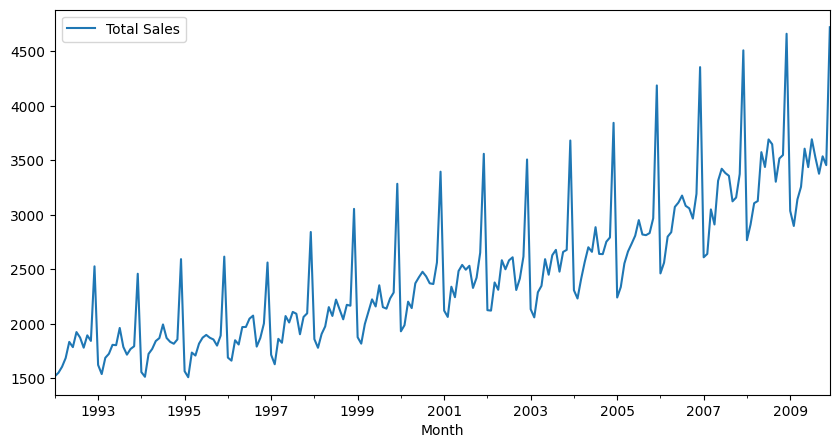

In [3]:
data.plot(y='Total Sales', figsize=[10,5]);

In [12]:
# trend + seasonal component => Holt Winters

from statsmodels.tsa.holtwinters import ExponentialSmoothing
# datum is ingesteld als index => slice operator

# train en test data
train = data['Total Sales']['1992-01-01':'2008-12-01']
test = data['Total Sales']['2009-01-01':'2009-12-01']

# trainen van het model
hw = ExponentialSmoothing(train, trend='add', seasonal='mul', seasonal_periods=12, freq='MS').fit()

# predicted data
predicted = hw.forecast(12)

# fitted values --> op elk tijdstip voorspelde waarde en werkelijke waarde
# komen op '1 lijn'
data['HW_fittedvalues'] = hw.fittedvalues
data.head()


,Total Sales,HW_fittedvalues
Month,,
1992-01-01,1519,1587.129111
1992-02-01,1551,1551.765565
1992-03-01,1606,1701.566895
1992-04-01,1686,1682.996067
1992-05-01,1834,1820.229865


In [ ]:
train.plot(legend=True, label='train')
hw.fittedvalues.plot(legend=True, label='fitted')

test.plot(legend=True, label='test')
predicted.plot(legend=True, label='predicted')

In [16]:
from sklearn.metrics import mean_absolute_error,mean_squared_error

print(f'MAE = {mean_absolute_error(test,predicted)}')

MAE = 121.38897856160781


## Source
Business Analytics Data Analysis & Decision Making